In [3]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [5]:
train_dir = 'D:/college/grad project/integrated/training'   
test_dir = 'D:/college/grad project/integrated/testing' 

In [7]:
# Image size
IMG_SIZE = (299, 299)

# Batch size
BATCH_SIZE = 32

# Number of classes
NUM_CLASSES = 4

In [9]:
# Prepare data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.2  # Use 20% of training data as validation
)

In [11]:

# Split training into training + validation
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Testing data generator
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 9345 images belonging to 4 classes.
Found 2333 images belonging to 4 classes.
Found 1705 images belonging to 4 classes.


In [13]:
# Load InceptionResNetV2 without the top layer
base_model = InceptionResNetV2(weights='imagenet', include_top=False, input_shape=(299, 299, 3))

In [17]:
# Freeze the base model
base_model.trainable = False

# Add custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

# Build the full model
model = Model(inputs=base_model.input, outputs=predictions)

In [19]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

In [21]:
# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('inceptionresnetv2_mri.h5', monitor='val_accuracy', save_best_only=True, verbose=1)

In [23]:
# Train only the custom head first
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint]
)

D:\anaconda\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4115 - loss: 1.3747
Epoch 1: val_accuracy improved from -inf to 0.60694, saving model to inceptionresnetv2_mri.h5


293/293 ━━━━━━━━━━━━━━━━━━━━ 866s 3s/step - accuracy: 0.4118 - loss: 1.3740 - val_accuracy: 0.6069 - val_loss: 0.9553
Epoch 2/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6600 - loss: 0.8624
Epoch 2: val_accuracy improved from 0.60694 to 0.67553, saving model to inceptionresnetv2_mri.h5


293/293 ━━━━━━━━━━━━━━━━━━━━ 840s 3s/step - accuracy: 0.6600 - loss: 0.8623 - val_accuracy: 0.6755 - val_loss: 0.8485
Epoch 3/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6875 - loss: 0.7923
Epoch 3: val_accuracy improved from 0.67553 to 0.68496, saving model to inceptionresnetv2_mri.h5


293/293 ━━━━━━━━━━━━━━━━━━━━ 837s 3s/step - accuracy: 0.6876 - loss: 0.7922 - val_accuracy: 0.6850 - val_loss: 0.8101
Epoch 4/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7214 - loss: 0.7002
Epoch 4: val_accuracy did not improve from 0.68496
293/293 ━━━━━━━━━━━━━━━━━━━━ 845s 3s/step - accuracy: 0.7214 - loss: 0.7002 - val_accuracy: 0.6717 - val_loss: 0.8049
Epoch 5/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7307 - loss: 0.6778
Epoch 5: val_accuracy improved from 0.68496 to 0.70853, saving model to inceptionresnetv2_mri.h5


...

293/293 ━━━━━━━━━━━━━━━━━━━━ 837s 3s/step - accuracy: 0.7547 - loss: 0.6363 - val_accuracy: 0.7162 - val_loss: 0.7391
Epoch 7/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7429 - loss: 0.6523
Epoch 7: val_accuracy did not improve from 0.71625
293/293 ━━━━━━━━━━━━━━━━━━━━ 839s 3s/step - accuracy: 0.7429 - loss: 0.6522 - val_accuracy: 0.7115 - val_loss: 0.7354
Epoch 8/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7635 - loss: 0.6136
Epoch 8: val_accuracy improved from 0.71625 to 0.73425, saving model to inceptionresnetv2_mri.h5


293/293 ━━━━━━━━━━━━━━━━━━━━ 839s 3s/step - accuracy: 0.7635 - loss: 0.6136 - val_accuracy: 0.7342 - val_loss: 0.6945
Epoch 9/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7593 - loss: 0.6133
Epoch 9: val_accuracy improved from 0.73425 to 0.74025, saving model to inceptionresnetv2_mri.h5


293/293 ━━━━━━━━━━━━━━━━━━━━ 848s 3s/step - accuracy: 0.7593 - loss: 0.6132 - val_accuracy: 0.7402 - val_loss: 0.6805
Epoch 10/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7601 - loss: 0.6089
Epoch 10: val_accuracy did not improve from 0.74025
293/293 ━━━━━━━━━━━━━━━━━━━━ 842s 3s/step - accuracy: 0.7601 - loss: 0.6088 - val_accuracy: 0.7381 - val_loss: 0.6873
Epoch 11/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7788 - loss: 0.5686
Epoch 11: val_accuracy did not improve from 0.74025
293/293 ━━━━━━━━━━━━━━━━━━━━ 839s 3s/step - accuracy: 0.7788 - loss: 0.5686 - val_accuracy: 0.7368 - val_loss: 0.6842
Epoch 12/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7830 - loss: 0.5696
Epoch 12: val_accuracy did not improve from 0.74025
293/293 ━━━━━━━━━━━━━━━━━━━━ 837s 3s/step - accuracy: 0.7830 - loss: 0.5696 - val_accuracy: 0.7390 - val_loss: 0.6779
Epoch 13/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7757 - loss: 0.5747
Epoch 13: val_accuracy impro

293/293 ━━━━━━━━━━━━━━━━━━━━ 837s 3s/step - accuracy: 0.7757 - loss: 0.5747 - val_accuracy: 0.7458 - val_loss: 0.6679
Epoch 14/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7799 - loss: 0.5696
Epoch 14: val_accuracy improved from 0.74582 to 0.75225, saving model to inceptionresnetv2_mri.h5


293/293 ━━━━━━━━━━━━━━━━━━━━ 835s 3s/step - accuracy: 0.7799 - loss: 0.5695 - val_accuracy: 0.7523 - val_loss: 0.6494
Epoch 15/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7959 - loss: 0.5391
Epoch 15: val_accuracy did not improve from 0.75225
293/293 ━━━━━━━━━━━━━━━━━━━━ 31930s 109s/step - accuracy: 0.7958 - loss: 0.5391 - val_accuracy: 0.7437 - val_loss: 0.6432


In [25]:
# Unfreeze the base model for fine-tuning
base_model.trainable = True

In [32]:
# Recompile the model (important after unfreezing)
model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

In [34]:
# Fine-tune the full model
fine_tune_history = model.fit(
    train_generator,
    epochs=10,  # Fine-tuning epochs
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9764 - loss: 0.0728
Epoch 1: val_accuracy improved from 0.93485 to 0.94899, saving model to inceptionresnetv2_mri.h5


293/293 ━━━━━━━━━━━━━━━━━━━━ 3028s 10s/step - accuracy: 0.9764 - loss: 0.0728 - val_accuracy: 0.9490 - val_loss: 0.1724
Epoch 2/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9837 - loss: 0.0523
Epoch 2: val_accuracy improved from 0.94899 to 0.95928, saving model to inceptionresnetv2_mri.h5


293/293 ━━━━━━━━━━━━━━━━━━━━ 2935s 10s/step - accuracy: 0.9837 - loss: 0.0522 - val_accuracy: 0.9593 - val_loss: 0.1617
Epoch 3/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9891 - loss: 0.0331
Epoch 3: val_accuracy did not improve from 0.95928
293/293 ━━━━━━━━━━━━━━━━━━━━ 2948s 10s/step - accuracy: 0.9891 - loss: 0.0331 - val_accuracy: 0.9541 - val_loss: 0.1637
Epoch 4/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.9893 - loss: 0.0292 
Epoch 4: val_accuracy did not improve from 0.95928
293/293 ━━━━━━━━━━━━━━━━━━━━ 4168s 14s/step - accuracy: 0.9893 - loss: 0.0292 - val_accuracy: 0.9559 - val_loss: 0.1557
Epoch 5/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.9919 - loss: 0.0278 
Epoch 5: val_accuracy improved from 0.95928 to 0.96057, saving model to inceptionresnetv2_mri.h5


293/293 ━━━━━━━━━━━━━━━━━━━━ 3501s 12s/step - accuracy: 0.9919 - loss: 0.0278 - val_accuracy: 0.9606 - val_loss: 0.1745
Epoch 6/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.9941 - loss: 0.0194 
Epoch 6: val_accuracy improved from 0.96057 to 0.96314, saving model to inceptionresnetv2_mri.h5


293/293 ━━━━━━━━━━━━━━━━━━━━ 3770s 13s/step - accuracy: 0.9941 - loss: 0.0194 - val_accuracy: 0.9631 - val_loss: 0.1562
Epoch 7/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.9940 - loss: 0.0180 
Epoch 7: val_accuracy improved from 0.96314 to 0.96357, saving model to inceptionresnetv2_mri.h5


293/293 ━━━━━━━━━━━━━━━━━━━━ 3356s 11s/step - accuracy: 0.9940 - loss: 0.0180 - val_accuracy: 0.9636 - val_loss: 0.1479
Epoch 8/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.9937 - loss: 0.0221
Epoch 8: val_accuracy did not improve from 0.96357
293/293 ━━━━━━━━━━━━━━━━━━━━ 3028s 10s/step - accuracy: 0.9937 - loss: 0.0221 - val_accuracy: 0.9631 - val_loss: 0.1462
Epoch 9/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9941 - loss: 0.0191
Epoch 9: val_accuracy did not improve from 0.96357
293/293 ━━━━━━━━━━━━━━━━━━━━ 2686s 9s/step - accuracy: 0.9941 - loss: 0.0191 - val_accuracy: 0.9636 - val_loss: 0.1708
Epoch 10/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9960 - loss: 0.0124
Epoch 10: val_accuracy improved from 0.96357 to 0.96700, saving model to inceptionresnetv2_mri.h5


293/293 ━━━━━━━━━━━━━━━━━━━━ 2722s 9s/step - accuracy: 0.9960 - loss: 0.0124 - val_accuracy: 0.9670 - val_loss: 0.1456


In [36]:
# Fine-tune for more epochs (optional continuation)
fine_tune_history = model.fit(
    train_generator,
    epochs=15,  # Add 5 more if you already did 10
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint],
    initial_epoch=10  # Start from where you left off
)

Epoch 11/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9946 - loss: 0.0175
Epoch 11: val_accuracy improved from 0.96700 to 0.96785, saving model to inceptionresnetv2_mri.h5


293/293 ━━━━━━━━━━━━━━━━━━━━ 2949s 10s/step - accuracy: 0.9946 - loss: 0.0175 - val_accuracy: 0.9679 - val_loss: 0.1509
Epoch 12/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.9976 - loss: 0.0080
Epoch 12: val_accuracy did not improve from 0.96785
293/293 ━━━━━━━━━━━━━━━━━━━━ 3086s 11s/step - accuracy: 0.9976 - loss: 0.0080 - val_accuracy: 0.9653 - val_loss: 0.1576
Epoch 13/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9966 - loss: 0.0125
Epoch 13: val_accuracy did not improve from 0.96785
293/293 ━━━━━━━━━━━━━━━━━━━━ 2927s 10s/step - accuracy: 0.9966 - loss: 0.0125 - val_accuracy: 0.9631 - val_loss: 0.1537
Epoch 14/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9975 - loss: 0.0082
Epoch 14: val_accuracy improved from 0.96785 to 0.96914, saving model to inceptionresnetv2_mri.h5


293/293 ━━━━━━━━━━━━━━━━━━━━ 2868s 10s/step - accuracy: 0.9975 - loss: 0.0082 - val_accuracy: 0.9691 - val_loss: 0.1479
Epoch 15/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9985 - loss: 0.0057
Epoch 15: val_accuracy did not improve from 0.96914
293/293 ━━━━━━━━━━━━━━━━━━━━ 2716s 9s/step - accuracy: 0.9985 - loss: 0.0057 - val_accuracy: 0.9601 - val_loss: 0.1659


In [40]:
model.save('saved_model/inceptionresnetv2_mri_final.keras')

In [42]:
from tensorflow.keras.models import load_model

model = load_model('saved_model/inceptionresnetv2_mri_final.keras')

D:\anaconda\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 494 variables whereas the saved optimizer has 986 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [44]:
loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

54/54 ━━━━━━━━━━━━━━━━━━━━ 169s 3s/step - accuracy: 0.9605 - loss: 0.2593
Test Loss: 0.2103
Test Accuracy: 0.9683


54/54 ━━━━━━━━━━━━━━━━━━━━ 3371s 63s/step


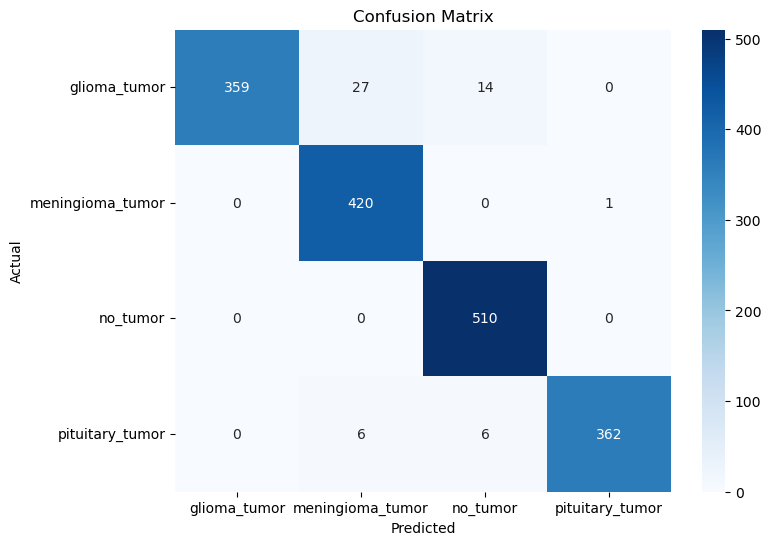

Classification Report:
                   precision    recall  f1-score   support

    glioma_tumor       1.00      0.90      0.95       400
meningioma_tumor       0.93      1.00      0.96       421
        no_tumor       0.96      1.00      0.98       510
 pituitary_tumor       1.00      0.97      0.98       374

        accuracy                           0.97      1705
       macro avg       0.97      0.97      0.97      1705
    weighted avg       0.97      0.97      0.97      1705



In [46]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions
pred_probs = model.predict(test_generator)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_generator.classes

# Class labels
class_labels = list(test_generator.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification report
report = classification_report(y_true, y_pred, target_names=class_labels)
print("Classification Report:\n", report)